# 02. AMR Profiling

Reproduces and extends the antimicrobial resistance analysis from Lee et al. (2023).

**Analysis sections:**
1. Phenotypic resistance overview — 79 isolates × 15 antibiotics
2. MDR distribution by species and isolation source
3. Resistance rate per antibiotic class
4. Species-level resistance heatmap
5. Genotypic AMR profile — Table 1 reproduction (19 WGS strains)
6. **Extended: Genotype–phenotype concordance scoring**

**Reference:** Lee et al. (2023), *Frontiers in Microbiology*, 14:1175304

In [1]:
# ── dependencies ──────────────────────────────────────────────
# pip install pandas numpy seaborn matplotlib plotly

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import plotly.express as px
import re
from pathlib import Path

PROC = Path('../data/processed')
RAW  = Path('../data/raw')
print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Load & clean data

In [2]:
# ── load processed files ──────────────────────────────────────
long = pd.read_csv(PROC / 'amr_phenotype_long.csv')
wide = pd.read_csv(PROC / 'amr_phenotype_wide.csv')

# ── normalise species_id (fix spacing inconsistencies) ────────
# e.g. 'A.salmonicida' → 'A. salmonicida', 'A. bestarium' → 'A. bestiarum'
species_fix = {
    'A.salmonicida'  : 'A. salmonicida',
    'A.bestiarum'    : 'A. bestiarum',
    'A. bestarium'   : 'A. bestiarum',
    'A. media ?'     : 'A. media',
}
long['species'] = long['species_id'].replace(species_fix)
wide['species'] = wide['species_id'].replace(species_fix)

# ── clean antibiotic & class names (strip trailing spaces) ────
long['antibiotic'] = long['antibiotic'].str.strip()
long['abx_class']  = long['abx_class'].str.strip()

# ── antibiotic short name map for plot labels ─────────────────
abx_short = {
    'Ampicillin AMP10'                       : 'AMP',
    'Mecillinam MEL10'                        : 'MEL',
    'Cefotaxime CTX30'                        : 'CTX',
    'ceftriaxone CRO30'                       : 'CRO',
    'Ciprofloxacin CIP1'                      : 'CIP',
    'Oxolinic acid OA'                        : 'OA',
    'Doxycycline DO30'                        : 'DO',
    'Tetracycline TE30'                       : 'TE',
    'Imipenem IPM10'                          : 'IPM',
    'Meropenem MEM10'                         : 'MEM',
    'Gentamycin  GM10'                        : 'GM',
    'Tobramycin TOB30'                        : 'TOB',
    'Erythromycin  EM15'                      : 'EM',
    'Florfenicol  FEC30'                      : 'FEC',
    'Trimethoprim/sulfamethoxazole  STX 25'   : 'STX',
}
long['abx_label'] = long['antibiotic'].map(abx_short)

# class order for plots
class_order = [
    'Beta-lactams', 'Cephalosporins', 'Quinolones', 'Carbapenems',
    'Tetracyclines', 'Aminoglycosides', 'Macrolides', 'Amphenicols'
]
# normalise class names to match class_order
class_fix = {'Tetracylines': 'Tetracyclines', 'Carbapenemems': 'Carbapenems',
             'Aminoglycosides ': 'Aminoglycosides'}
long['abx_class'] = long['abx_class'].replace(class_fix)

# species order (consistent across all plots)
species_order = [
    'A. salmonicida', 'A. bestiarum', 'A. piscicola',
    'A. hydrophila', 'A. dhakensis', 'A. caviae',
    'A. media', 'A. rivipollensis'
]
species_palette = {
    'A. salmonicida'   : '#E07B54',
    'A. piscicola'     : '#5B8DB8',
    'A. bestiarum'     : '#6BAF92',
    'A. media'         : '#9B7BB8',
    'A. rivipollensis' : '#D4A843',
    'A. caviae'        : '#C4706A',
    'A. hydrophila'    : '#7BA87B',
    'A. dhakensis'     : '#8AA6C4',
}

print(f'long: {long.shape} | wide: {wide.shape}')
print(f'Isolates: {long["isolate_id"].nunique()} | Species: {long["species"].nunique()}')
print(f'Antibiotics: {long["antibiotic"].nunique()} | Classes: {long["abx_class"].nunique()}')

long: (1185, 11) | wide: (79, 21)
Isolates: 77 | Species: 8
Antibiotics: 15 | Classes: 8


---
## 2. Phenotypic resistance overview

In [3]:
# ── resistance rate per antibiotic ────────────────────────────
# group by antibiotic, compute %R %I %S
abx_stats = (
    long.groupby(['abx_class', 'antibiotic', 'abx_label'])['phenotype']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .unstack(fill_value=0)
    .reset_index()
)
# ensure R I S columns exist
for col in ['R', 'I', 'S']:
    if col not in abx_stats.columns:
        abx_stats[col] = 0

# sort by class order then by %R descending
abx_stats['class_rank'] = abx_stats['abx_class'].map(
    {c: i for i, c in enumerate(class_order)}
)
abx_stats = abx_stats.sort_values(['class_rank', 'R'], ascending=[True, False])

print('Resistance rate (%) per antibiotic:')
print(abx_stats[['abx_class', 'abx_label', 'R', 'I', 'S']].to_string(index=False))

Resistance rate (%) per antibiotic:
      abx_class abx_label     R    I     S
   Beta-lactams       AMP 100.0  0.0   0.0
   Beta-lactams       MEL   0.0  0.0 100.0
 Cephalosporins       CTX   2.5 30.4  67.1
 Cephalosporins       CRO   0.0 30.4  69.6
     Quinolones        OA  21.5 34.2  44.3
     Quinolones       CIP   0.0  0.0 100.0
    Carbapenems       IPM  10.1 16.5  73.4
    Carbapenems       MEM   1.3  0.0  98.7
  Tetracyclines        DO   0.0  0.0 100.0
  Tetracyclines        TE   0.0  0.0 100.0
Aminoglycosides        GM   0.0  0.0 100.0
Aminoglycosides       TOB   0.0  2.5  97.5
     Macrolides        EM  57.0  0.0  43.0
    Amphenicols       FEC  48.1  0.0  51.9
    Amphenicols       STX   0.0  1.3  98.7


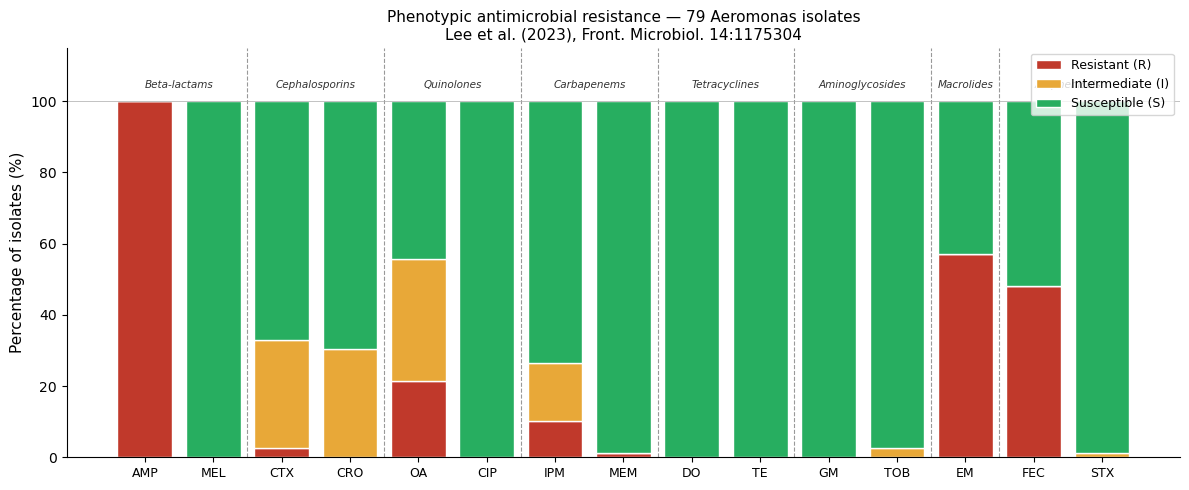

Saved: fig_amr_overview.png


In [4]:
# ── stacked bar: %R / %I / %S per antibiotic ─────────────────
fig, ax = plt.subplots(figsize=(12, 5))

labels  = abx_stats['abx_label'].tolist()
r_vals  = abx_stats['R'].tolist()
i_vals  = abx_stats['I'].tolist()
s_vals  = abx_stats['S'].tolist()
x = np.arange(len(labels))

bar_r = ax.bar(x, r_vals, color='#C0392B', label='Resistant (R)', edgecolor='white')
bar_i = ax.bar(x, i_vals, bottom=r_vals, color='#E8A838',
               label='Intermediate (I)', edgecolor='white')
bar_s = ax.bar(x, s_vals,
               bottom=[r + i for r, i in zip(r_vals, i_vals)],
               color='#27AE60', label='Susceptible (S)', edgecolor='white')

# add class dividers
class_boundaries = []
prev_class = None
for idx, row in abx_stats.iterrows():
    if row['abx_class'] != prev_class:
        class_boundaries.append(abx_stats.index.get_loc(idx))
        prev_class = row['abx_class']

for boundary in class_boundaries[1:]:
    ax.axvline(boundary - 0.5, color='#555555', linestyle='--',
               linewidth=0.8, alpha=0.6)

# class labels on top
for i, cls in enumerate(class_order):
    cls_abx = abx_stats[abx_stats['abx_class'] == cls]
    if len(cls_abx) == 0:
        continue
    positions = [abx_stats.index.get_loc(idx) for idx in cls_abx.index]
    mid = np.mean(positions)
    ax.text(mid, 103, cls, ha='center', va='bottom', fontsize=7.5,
            fontstyle='italic', color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Percentage of isolates (%)', fontsize=11)
ax.set_ylim(0, 115)
ax.set_title(
    'Phenotypic antimicrobial resistance — 79 Aeromonas isolates\n'
    'Lee et al. (2023), Front. Microbiol. 14:1175304',
    fontsize=11
)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(100, color='#AAAAAA', linewidth=0.5)
sns.despine()

plt.tight_layout()
plt.savefig(PROC / 'fig_amr_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_amr_overview.png')

---
## 3. MDR distribution

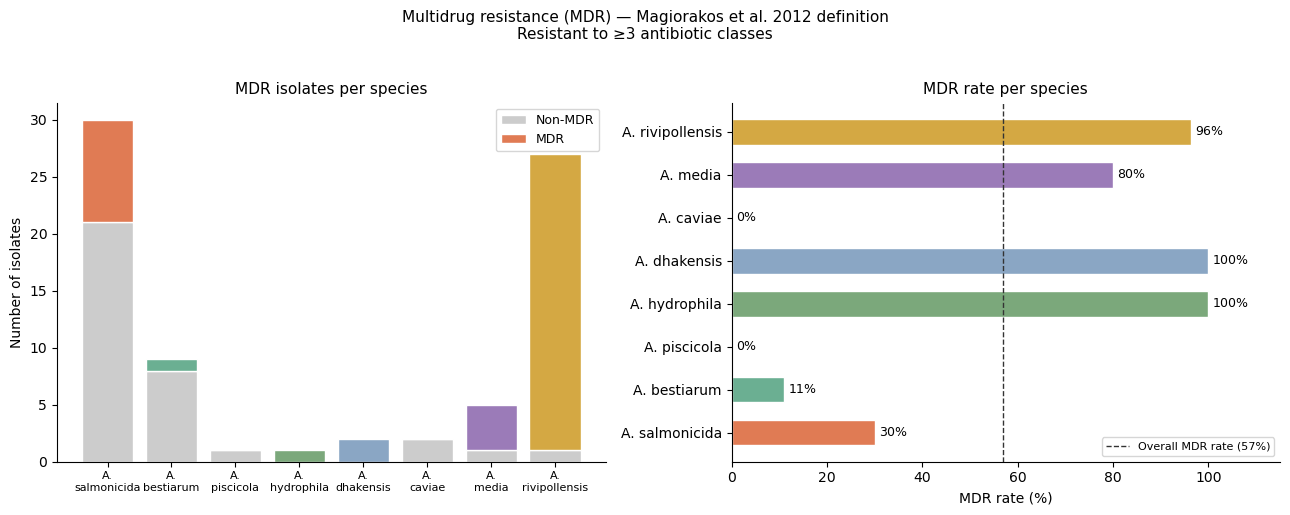

Saved: fig_mdr_by_species.png


In [5]:
# ── MDR rate per species ──────────────────────────────────────
# one row per isolate
isolate_meta = (
    long[['isolate_id', 'species', 'source', 'MDR']]
    .drop_duplicates('isolate_id')
)

mdr_by_species = (
    isolate_meta.groupby('species')['MDR']
    .agg(total='count', mdr_count='sum')
    .assign(mdr_pct=lambda x: x['mdr_count'] / x['total'] * 100)
    .reset_index()
)
# sort by species_order
mdr_by_species['rank'] = mdr_by_species['species'].map(
    {s: i for i, s in enumerate(species_order)}
)
mdr_by_species = mdr_by_species.sort_values('rank')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: MDR count stacked bar per species
x = np.arange(len(mdr_by_species))
colors = [species_palette.get(sp, '#CCCCCC')
          for sp in mdr_by_species['species']]

non_mdr = mdr_by_species['total'] - mdr_by_species['mdr_count']
axes[0].bar(x, non_mdr, color='#CCCCCC', label='Non-MDR', edgecolor='white')
axes[0].bar(x, mdr_by_species['mdr_count'], bottom=non_mdr,
            color=colors, label='MDR', edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [s.replace('A. ', 'A.\n') for s in mdr_by_species['species']],
    fontsize=8
)
axes[0].set_ylabel('Number of isolates', fontsize=10)
axes[0].set_title('MDR isolates per species', fontsize=11)
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# right: MDR rate % bar
bars = axes[1].barh(
    mdr_by_species['species'],
    mdr_by_species['mdr_pct'],
    color=colors, edgecolor='white', height=0.6
)
axes[1].bar_label(bars, fmt='%.0f%%', padding=3, fontsize=9)
axes[1].axvline(57, color='#333333', linestyle='--', linewidth=1,
                label='Overall MDR rate (57%)')
axes[1].set_xlabel('MDR rate (%)', fontsize=10)
axes[1].set_title('MDR rate per species', fontsize=11)
axes[1].set_xlim(0, 115)
axes[1].legend(fontsize=8)
sns.despine(ax=axes[1])

plt.suptitle('Multidrug resistance (MDR) — Magiorakos et al. 2012 definition\n'
             'Resistant to ≥3 antibiotic classes',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(PROC / 'fig_mdr_by_species.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_mdr_by_species.png')

---
## 4. Species-level resistance heatmap

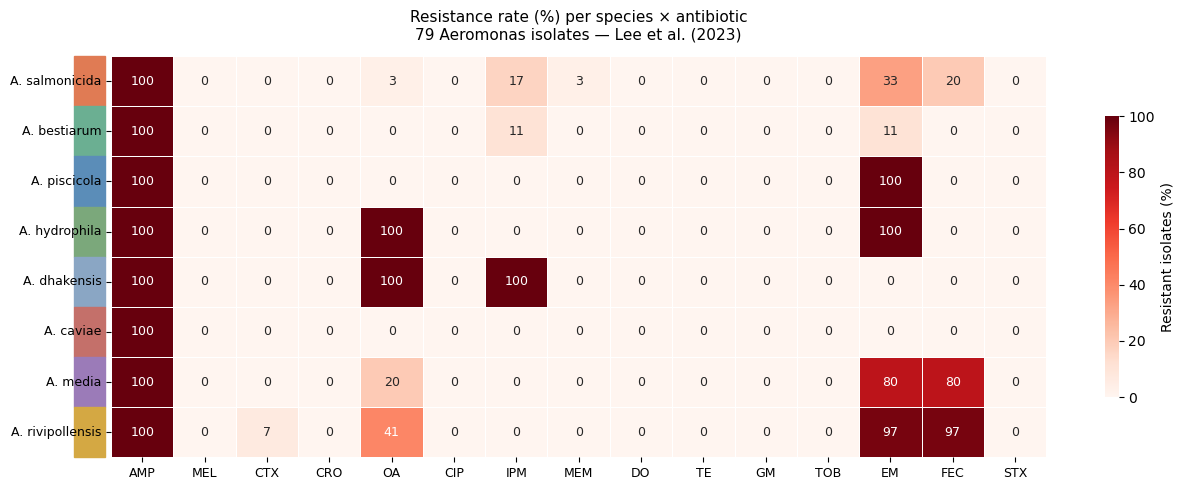

Saved: fig_resistance_heatmap.png


In [6]:
# ── % resistant per species × antibiotic ─────────────────────
resist_matrix = (
    long[long['phenotype'].notna()]
    .assign(is_R=lambda x: (x['phenotype'] == 'R').astype(int))
    .groupby(['species', 'abx_label'])['is_R']
    .mean()
    .mul(100)
    .unstack('abx_label')
    .fillna(0)
)

# reorder rows and columns
resist_matrix = resist_matrix.reindex(
    [s for s in species_order if s in resist_matrix.index]
)

# column order: sorted by class then by overall resistance
abx_label_to_class = {
    v: long[long['abx_label']==v]['abx_class'].iloc[0]
    for v in resist_matrix.columns
    if v in long['abx_label'].values
}
col_order = sorted(
    resist_matrix.columns,
    key=lambda c: (class_order.index(abx_label_to_class.get(c, 'z')),
                   -resist_matrix[c].mean())
)
resist_matrix = resist_matrix[col_order]

# ── heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

sns.heatmap(
    resist_matrix,
    ax=ax,
    cmap='Reds',
    vmin=0, vmax=100,
    annot=True, fmt='.0f',
    annot_kws={'size': 9},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Resistant isolates (%)', 'shrink': 0.7}
)

# species color bar on left
for i, sp in enumerate(resist_matrix.index):
    color = species_palette.get(sp, '#CCCCCC')
    ax.add_patch(plt.Rectangle(
        (-0.6, i), 0.5, 1,
        color=color, clip_on=False, transform=ax.transData
    ))

ax.set_title(
    'Resistance rate (%) per species × antibiotic\n'
    '79 Aeromonas isolates — Lee et al. (2023)',
    fontsize=11, pad=12
)
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.savefig(PROC / 'fig_resistance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_resistance_heatmap.png')

---
## 5. Genotypic AMR profile — Table 1 reproduction (19 WGS strains)

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_14192\2040886804.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  heatmap_binary = table1[gene_cols].applymap(lambda x: 1 if x != '' else 0)


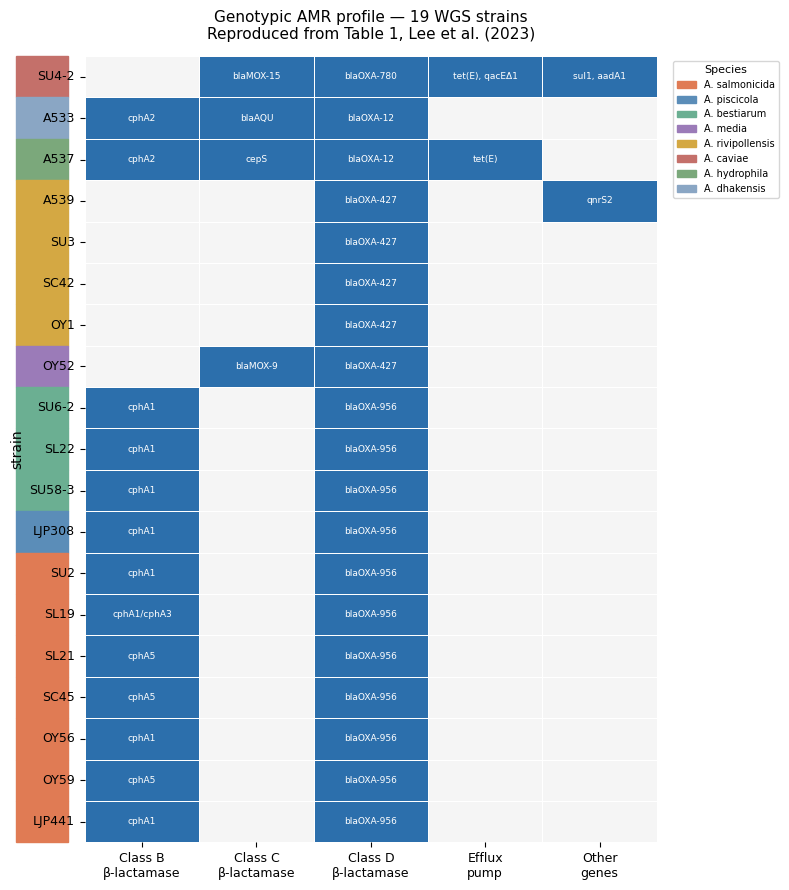

Saved: fig_genotypic_amr.png


In [7]:
# ── Table 1 from paper: genotypic AMR of 19 WGS strains ───────
# manually encoded from Table 1 (Lee et al. 2023)
# columns: strain, species, beta_lactamase_classB, classC, classD,
#          efflux_pump, other_genes

table1 = pd.DataFrame([
    # strain        species           classB        classC              classD           efflux            other
    ['SU4-2',   'A. caviae',          '',           'blaMOX-15',        'blaOXA-780',    'tet(E), qacEΔ1', 'sul1, aadA1'],
    ['A533',    'A. dhakensis',       'cphA2',      'blaAQU',           'blaOXA-12',     '',               ''],
    ['A537',    'A. hydrophila',      'cphA2',      'cepS',             'blaOXA-12',     'tet(E)',          ''],
    ['A539',    'A. rivipollensis',   '',           '',                 'blaOXA-427',    '',               'qnrS2'],
    ['SU3',     'A. rivipollensis',   '',           '',                 'blaOXA-427',    '',               ''],
    ['SC42',    'A. rivipollensis',   '',           '',                 'blaOXA-427',    '',               ''],
    ['OY1',     'A. rivipollensis',   '',           '',                 'blaOXA-427',    '',               ''],
    ['OY52',    'A. media',           '',           'blaMOX-9',         'blaOXA-427',    '',               ''],
    ['SU6-2',   'A. bestiarum',       'cphA1',      '',                 'blaOXA-956',    '',               ''],
    ['SL22',    'A. bestiarum',       'cphA1',      '',                 'blaOXA-956',    '',               ''],
    ['SU58-3',  'A. bestiarum',       'cphA1',      '',                 'blaOXA-956',    '',               ''],
    ['LJP308',  'A. piscicola',       'cphA1',      '',                 'blaOXA-956',    '',               ''],
    ['SU2',     'A. salmonicida',     'cphA1',      '',                 'blaOXA-956',    '',               ''],
    ['SL19',    'A. salmonicida',     'cphA1/cphA3','',                 'blaOXA-956',    '',               ''],
    ['SL21',    'A. salmonicida',     'cphA5',      '',                 'blaOXA-956',    '',               ''],
    ['SC45',    'A. salmonicida',     'cphA5',      '',                 'blaOXA-956',    '',               ''],
    ['OY56',    'A. salmonicida',     'cphA1',      '',                 'blaOXA-956',    '',               ''],
    ['OY59',    'A. salmonicida',     'cphA5',      '',                 'blaOXA-956',    '',               ''],
    ['LJP441',  'A. salmonicida',     'cphA1',      '',                 'blaOXA-956',    '',               ''],
],
columns=['strain', 'species', 'class_B', 'class_C', 'class_D', 'efflux_pump', 'other_genes']
)

# ── visualise as annotated heatmap ────────────────────────────
# encode presence/absence for heatmap
gene_cols = ['class_B', 'class_C', 'class_D', 'efflux_pump', 'other_genes']
heatmap_binary = table1[gene_cols].applymap(lambda x: 1 if x != '' else 0)
heatmap_binary.index = table1['strain']

# species color bar
row_colors = pd.Series(
    [species_palette.get(sp, '#CCCCCC') for sp in table1['species']],
    index=table1['strain']
)

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(
    heatmap_binary,
    ax=ax,
    cmap=['#F5F5F5', '#2C6FAC'],
    linewidths=0.5,
    linecolor='white',
    cbar=False,
    annot=table1[gene_cols].values,
    fmt='',
    annot_kws={'size': 6.5}
)

# species color bar on left
for i, sp in enumerate(table1['species']):
    color = species_palette.get(sp, '#CCCCCC')
    ax.add_patch(plt.Rectangle(
        (-0.6, i), 0.45, 1,
        color=color, clip_on=False, transform=ax.transData
    ))

ax.set_xticklabels(
    ['Class B\nβ-lactamase', 'Class C\nβ-lactamase', 'Class D\nβ-lactamase',
     'Efflux\npump', 'Other\ngenes'],
    fontsize=9, rotation=0
)
ax.set_yticklabels(table1['strain'], fontsize=9, rotation=0)
ax.set_title(
    'Genotypic AMR profile — 19 WGS strains\n'
    'Reproduced from Table 1, Lee et al. (2023)',
    fontsize=11, pad=12
)

# legend
handles = [mpatches.Patch(color=c, label=s)
           for s, c in species_palette.items()
           if s in table1['species'].values]
ax.legend(handles=handles, title='Species', bbox_to_anchor=(1.02, 1),
          loc='upper left', fontsize=7, title_fontsize=8)

plt.tight_layout()
plt.savefig(PROC / 'fig_genotypic_amr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_genotypic_amr.png')

---
## 6. Extended: Genotype–phenotype concordance scoring

> *"Some discrepancies between genotypic and phenotypic resistance were observed"*  
> — Lee et al. (2023), Discussion

This section quantifies that statement. For each of the 19 WGS strains, we compare:
- **Predicted resistance** from genotype (β-lactamase class → expected phenotype)
- **Observed resistance** from disk diffusion

Concordance = proportion of antibiotics where genotype prediction matches phenotype.

In [8]:
# ── genotype → expected resistance prediction rules ───────────
# based on known β-lactamase substrate spectra (literature)
# class B (cphA): carbapenems
# class C (blaMOX, blaAQU, cepS): cephalosporins
# class D (blaOXA): penicillins, some cephalosporins
# qnrS2: quinolones
# sul1: sulfonamides → STX

geno_predictions = {
    # strain: set of antibiotic labels predicted resistant from genotype
    'SU4-2'  : {'AMP', 'STX'},
    'A533'   : {'AMP', 'CTX', 'CRO'},
    'A537'   : {'AMP', 'CTX', 'CRO'},
    'A539'   : {'AMP', 'OA', 'CIP'},
    'SU3'    : {'AMP'},
    'SC42'   : {'AMP'},
    'OY1'    : {'AMP'},
    'OY52'   : {'AMP'},
    'SU6-2'  : {'AMP', 'IPM'},
    'SL22'   : {'AMP', 'IPM'},
    'SU58-3' : {'AMP', 'IPM'},
    'LJP308' : {'AMP', 'IPM'},
    'SU2'    : {'AMP', 'IPM'},
    'SL19'   : {'AMP', 'IPM'},
    'SL21'   : {'AMP', 'IPM'},
    'SC45'   : {'AMP', 'IPM'},
    'OY56'   : {'AMP', 'IPM'},
    'OY59'   : {'AMP', 'IPM', 'MEM'},
    'LJP441' : {'AMP', 'IPM'},
}

# ── observed phenotype for 19 WGS strains ─────────────────────
wgs_strains = list(geno_predictions.keys())

# some strain IDs differ slightly between Table S2 and Table 1
strain_alias = {'SU4-2': 'SU4', 'SU6-2': 'SU6-2'}

all_abx_labels = list(abx_short.values())

records = []
for strain in wgs_strains:
    lookup_id = strain_alias.get(strain, strain)
    obs = long[
        (long['isolate_id'] == lookup_id) &
        (long['phenotype'].notna())
    ].set_index('abx_label')['phenotype'].to_dict()

    if not obs:
        # try partial match
        matches = long[long['isolate_id'].str.startswith(strain[:3])]
        if len(matches) > 0:
            obs = matches.set_index('abx_label')['phenotype'].to_dict()

    geno_pred = geno_predictions[strain]
    tp = fp = tn = fn = 0

    for abx in all_abx_labels:
        pred_R  = abx in geno_pred
        obs_ph  = obs.get(abx)
        if obs_ph is None:
            continue
        obs_R = (obs_ph == 'R')

        if pred_R and obs_R:     tp += 1
        elif pred_R and not obs_R: fp += 1
        elif not pred_R and obs_R: fn += 1
        else:                      tn += 1

    total = tp + fp + tn + fn
    concordance = (tp + tn) / total * 100 if total > 0 else None
    species = table1.set_index('strain')['species'].get(strain, '')

    records.append({
        'strain'     : strain,
        'species'    : species,
        'TP'         : tp,
        'FP'         : fp,
        'TN'         : tn,
        'FN'         : fn,
        'concordance': concordance
    })

concordance_df = pd.DataFrame(records)
concordance_df.to_csv(PROC / 'genotype_phenotype_concordance.csv', index=False)
print('genotype_phenotype_concordance.csv saved')
print()
print(concordance_df[['strain','species','TP','FP','FN','TN','concordance']]
      .sort_values('concordance').to_string(index=False))

genotype_phenotype_concordance.csv saved

strain          species  TP  FP  FN  TN  concordance
 SU4-2        A. caviae   1   1   3  10    73.333333
  A533     A. dhakensis   1   2   2  10    73.333333
  A537    A. hydrophila   1   2   2  10    73.333333
   SU3 A. rivipollensis   1   0   4  10    73.333333
   SU2   A. salmonicida   1   1   3  10    73.333333
  OY56   A. salmonicida   1   1   2  11    80.000000
  OY52         A. media   1   0   2  12    86.666667
   OY1 A. rivipollensis   1   0   2  12    86.666667
LJP308     A. piscicola   1   1   1  12    86.666667
  SC42 A. rivipollensis   1   0   2  12    86.666667
  OY59   A. salmonicida   3   0   2  10    86.666667
  A539 A. rivipollensis   2   1   0  12    93.333333
SU58-3     A. bestiarum   1   1   0  13    93.333333
  SL19   A. salmonicida   2   0   1  12    93.333333
  SL22     A. bestiarum   2   0   1  12    93.333333
 SU6-2     A. bestiarum   1   1   0  13    93.333333
  SC45   A. salmonicida   2   0   1  12    93.333333
  SL

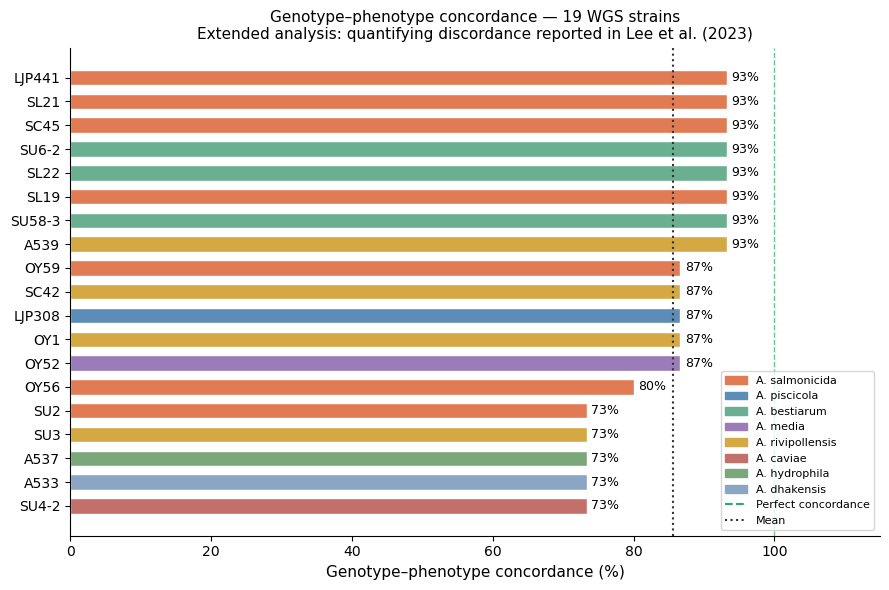

Saved: fig_concordance.png


In [9]:
# ── concordance visualisation ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

conc_sorted = concordance_df.sort_values('concordance')
colors = [species_palette.get(sp, '#CCCCCC') for sp in conc_sorted['species']]

bars = ax.barh(conc_sorted['strain'], conc_sorted['concordance'],
               color=colors, edgecolor='white', height=0.65)
ax.bar_label(bars, fmt='%.0f%%', padding=3, fontsize=9)

ax.axvline(100, color='#27AE60', linestyle='--', linewidth=1,
           alpha=0.7, label='Perfect concordance')
ax.axvline(concordance_df['concordance'].mean(), color='#333333',
           linestyle=':', linewidth=1.5,
           label=f'Mean ({concordance_df["concordance"].mean():.0f}%)')

ax.set_xlabel('Genotype–phenotype concordance (%)', fontsize=11)
ax.set_title(
    'Genotype–phenotype concordance — 19 WGS strains\n'
    'Extended analysis: quantifying discordance reported in Lee et al. (2023)',
    fontsize=11
)
ax.set_xlim(0, 115)

# species legend
handles = [mpatches.Patch(color=c, label=s)
           for s, c in species_palette.items()
           if s in conc_sorted['species'].values]
handles += [plt.Line2D([0], [0], color='#27AE60', linestyle='--', label='Perfect concordance'),
            plt.Line2D([0], [0], color='#333333', linestyle=':', label=f'Mean')]
ax.legend(handles=handles, fontsize=8, loc='lower right')
sns.despine()

plt.tight_layout()
plt.savefig(PROC / 'fig_concordance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_concordance.png')